# 02 GLUE Ensemble — CI Band Visualization

Monte Carlo sampling via spotpy with NSE behavioral threshold.
Forward model: Q_sim = a * Q_wam + b (linear scaling correction).

**Run this notebook from the repo root directory:** `jupyter notebook`



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from red_tide_reanalysis.ingestion.obs_loader import load_observations
from red_tide_reanalysis.ingestion.wam_loader import load_wam_model
from red_tide_reanalysis.ingestion.align import align_obs_model
from red_tide_reanalysis.glue.method import GLUEMethod
from red_tide_reanalysis.writers.ensemble_writer import write_ensemble_csv
from red_tide_reanalysis.writers.stats_writer import write_stats_csv

## 1. Load and Align Data

In [2]:
obs_raw = load_observations("../Observation_Data/Observed_flow_ARCADIA_FL.csv")
wam_raw = load_wam_model("../Synthetic_Model_Data/Station 02296750 (ARCADIA)_reach000084_83.csv")
obs, model = align_obs_model(obs_raw, wam_raw)
print(f"Aligned series: {len(obs)} timesteps, {obs.index[0].date()} to {obs.index[-1].date()}")

Aligned series: 9131 timesteps, 1999-01-01 to 2023-12-31


## 2. Configure and Run GLUE

In [3]:
method = GLUEMethod(
    n_members=200,
    station_id="02296750_peace_river",
    n_draws=10000,
    nse_threshold=0.5,
    a_bounds=(0.1, 3.0),
    b_bounds=(-50.0, 50.0),
)
result = method.run(obs, model, n_members=200, seed=42)
print(f"GLUE: {result.config['n_behavioral']} behavioral / {result.config['n_draws']} total draws (NSE >= {result.config['nse_threshold']})")
print(f"Ensemble shape: {result.members.shape}")

Initializing the  Monte Carlo (MC) sampler  with  10000  repetitions
Starting the MC algorithm with 10000 repetitions...
Initialize database...
['csv', 'hdf5', 'ram', 'sql', 'custom', 'noData']
2145 of 10000, min objf=-8.86777, max objf=0.862195, time remaining: 00:00:07
4319 of 10000, min objf=-8.86777, max objf=0.86247, time remaining: 00:00:05
6493 of 10000, min objf=-8.86777, max objf=0.863911, time remaining: 00:00:03
8707 of 10000, min objf=-8.86777, max objf=0.863911, time remaining: 00:00:01

*** Final SPOTPY summary ***
Total Duration: 9.16 seconds
Total Repetitions: 10000
Minimal objective value: -8.86777
Corresponding parameter setting:
a: 2.99078
b: 49.515
Maximal objective value: 0.863911
Corresponding parameter setting:
a: 0.902571
b: 0.144144
******************************

GLUE: 1907 behavioral / 10000 total draws (NSE >= 0.5)
Ensemble shape: (200, 9131)


## 3. Threshold Sensitivity Table

Shows behavioral vs. non-behavioral parameter set counts at three NSE cutoff values.

In [4]:
import spotpy
import spotpy.algorithms
import spotpy.objectivefunctions
import spotpy.parameter
from red_tide_reanalysis.glue.method import _GLUESpotSetup

# Re-run a fresh MC sample with the same seed for sensitivity diagnostics
np.random.seed(42)
spot_setup = _GLUESpotSetup(
    obs.values, model.values,
    a_bounds=(0.1, 3.0),
    b_bounds=(-50.0, 50.0),
)
sampler = spotpy.algorithms.mc(spot_setup, dbname="sensitivity", dbformat="ram", save_sim=False)
sampler.sample(10000)
raw_results = sampler.getdata()
# spotpy 1.6.7: field name is 'like1' (verified via dtype.names diagnostic)
nse_scores = np.squeeze(raw_results["like1"])

thresholds = [0.3, 0.5, 0.7]
total = len(nse_scores)
rows = [
    {
        "NSE Threshold": t,
        "Behavioral": int(np.sum(nse_scores >= t)),
        "Non-Behavioral": int(np.sum(nse_scores < t)),
        "% Behavioral": f"{100 * np.sum(nse_scores >= t) / total:.1f}%",
    }
    for t in thresholds
]
df_sensitivity = pd.DataFrame(rows)
print(f"\nGLUE Threshold Sensitivity (total draws: {total})")
display(df_sensitivity)

Initializing the  Monte Carlo (MC) sampler  with  10000  repetitions
Starting the MC algorithm with 10000 repetitions...
Initialize database...
['csv', 'hdf5', 'ram', 'sql', 'custom', 'noData']
2188 of 10000, min objf=-8.86777, max objf=0.862195, time remaining: 00:00:07
4361 of 10000, min objf=-8.86777, max objf=0.86247, time remaining: 00:00:05
6537 of 10000, min objf=-8.86777, max objf=0.863911, time remaining: 00:00:03
8716 of 10000, min objf=-8.86777, max objf=0.863911, time remaining: 00:00:01

*** Final SPOTPY summary ***
Total Duration: 9.2 seconds
Total Repetitions: 10000
Minimal objective value: -8.86777
Corresponding parameter setting:
a: 2.99078
b: 49.515
Maximal objective value: 0.863911
Corresponding parameter setting:
a: 0.902571
b: 0.144144
******************************


GLUE Threshold Sensitivity (total draws: 10000)


,NSE Threshold,Behavioral,Non-Behavioral,% Behavioral
0,0.3,3037,6963,30.4%
1,0.5,1907,8093,19.1%
2,0.7,863,9137,8.6%


## 4. CI Band Visualization

5th–95th percentile shaded band from the 200-member GLUE ensemble.
Observations as scatter points; WAM model output as a dashed red line.

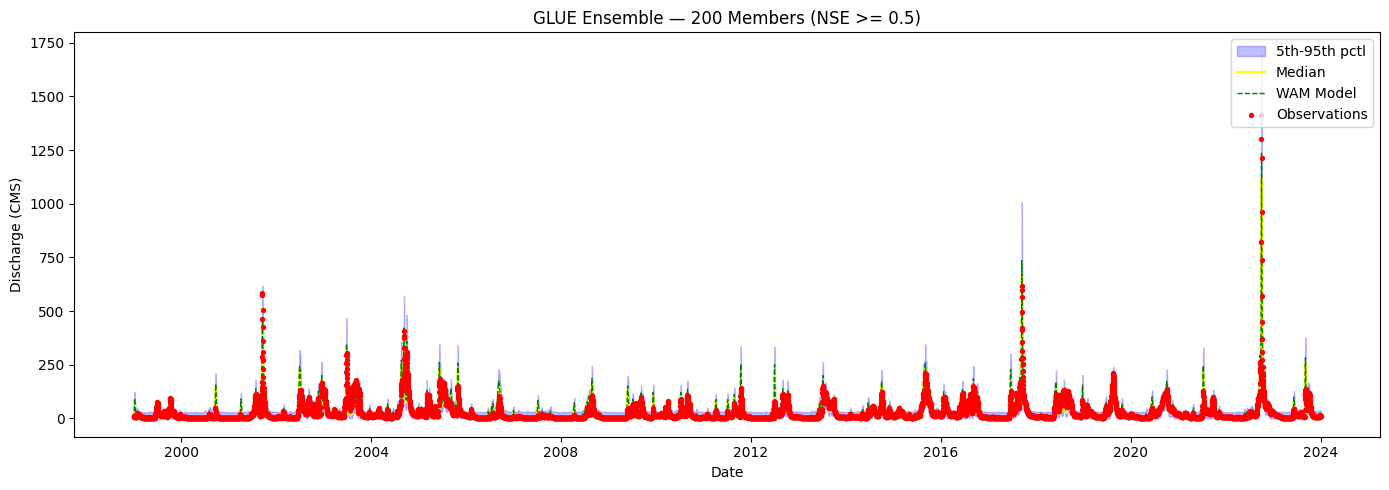

In [5]:
p5  = np.percentile(result.members, 5,  axis=0)
p95 = np.percentile(result.members, 95, axis=0)
median = np.median(result.members, axis=0)

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(result.time_index, p5, p95, alpha=0.25, color="blue", label="5th-95th pctl")
ax.plot(result.time_index, median, color="yellow", linewidth=1.5, label="Median")
ax.plot(result.time_index, result.model_output.values, color="green", linewidth=1, linestyle="--", label="WAM Model")
ax.scatter(result.time_index, result.observations.values, color="red", s=8, zorder=5, label="Observations")
ax.set_xlabel("Date")
ax.set_ylabel("Discharge (CMS)")
ax.set_title("GLUE Ensemble — 200 Members (NSE >= 0.5)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 5. Export CSVs

In [6]:
output_dir = Path("data/outputs")
ens_path = write_ensemble_csv(result, output_dir / "ensembles")
stats_path = write_stats_csv(result, output_dir / "stats")
print(f"Ensemble CSV: {ens_path}")
print(f"Stats CSV:    {stats_path}")

Ensemble CSV: data\outputs\ensembles\glue_02296750_peace_river_discharge_members.csv
Stats CSV:    data\outputs\stats\glue_02296750_peace_river_discharge_stats.csv


## Summary

- Forward model: Q_sim = a * Q_wam + b (2-parameter linear scaling)
- MC sampling: 10,000 draws via spotpy
- Operating NSE threshold: 0.5
- Ensemble size: 200 members (resampled with replacement from behavioral sets)
- Output files: `data/outputs/ensembles/` and `data/outputs/stats/`